# 18.2 — Window dashboard: the same dashboard grammar, but the points are WINDOWS

> ### ONE STRATEGY, FOUR OBSERVATION WINDOWS. THIS IS NOT A STRATEGY COMPARISON.
>
> `18_final_trio_dashboard.ipynb` plots three *strategies* on one window. This
> notebook keeps that dashboard grammar — iso-ratio risk–return map, unitless
> ratio ladder — and swaps what a point means: **every point here is the same
> single line observed over a different window.** There is nothing to rank
> against anything else. The spread between the points is a spread between
> *start dates*, not between strategies.
>
> The line is the static 25%-each buy-and-hold basket **SWDA.L / XLK / IAU / BIL**,
> bought once and never rebalanced — `15_3_extended_timeframe_static_bh.ipynb`'s
> subject, re-cut into nb18's visual language.

Four windows, each **buying fresh at its own start** (buy-and-hold holds *shares*,
so slicing a longer line inherits years of weight drift and silently answers a
different question — `15_3` quantifies that: sliced 2016 gives CAGR 17.5% / maxDD
-24.2%, bought fresh 15.4% / -19.6%):

| rung | buy | hold to | artifact |
|---|---|---|---|
| Full 16.7y | 2009-09-25 | 2026-05-29 (release pin) | `static_bh_equity_2009_2026.parquet` |
| 16.4y | 2009-09-25 | 2026-01-30 | same artifact, cut short |
| 10.0y | 2016-02-01 | 2026-01-30 | `static_bh_equity_2016_2026.parquet` |
| 7.1y | 2019-01-02 | 2026-01-30 | `static_bh_equity_2019_2026.parquet` |

Only the *end* is cut to a common 2026-01-30 (same purchase, shorter holding
period — legitimate); starts are never re-sliced. The Full rung is the only row
with a different end and is drawn as a diamond throughout.

### Three things that must be read before the charts

1. **The AI macro-factor and SJM×crowding lines cannot appear here before 2019 —
   at all.** Their loadings and scores are outputs of an LLM (`openai/gpt-oss-20b`
   via NVIDIA NIM), and those outputs exist only for the 2019+ rebalance dates;
   the response cache holds **zero pre-2019 replies**. There is no earlier history
   to plot for them, only earlier history that was never scored. Nothing here
   extrapolates them backwards, and no point on these charts is one of them.
2. **In-sample by construction.** Carried verbatim from `scripts/build_static_bh.py`:
   the four ETFs were *selected* by the Sharpe Stability Ratio computed over an
   overlapping window (nb02/nb03). Every rung below is a hindsight-selected static
   portfolio, never attainable skill — and more history does not launder the
   selection, it only shows it under more weather.
3. **The headline is a decay, and it is unflattering.** Sharpe falls **1.30**
   (7.1y) → **1.20** (10y) → **0.93** (16.4y) with the same basket, the same
   construction and the same end date. Only the buy date moves. The risk-adjusted
   case for this line is substantially an artifact of starting in 2019.

Metrics come from the shared `macro_framework.evaluation.metric_block` and every
stability verdict from `macro_framework.ssr.ssr_inference` — the same authorities
`15_2` / `15_3` / `18` use. This notebook contributes a re-cut, not a statistic.

> SPY is **price-only** (dividends missing) and the regressions run at rf=0, so
> the regression intercept and the appraisal ratio are internal same-source
> comparisons, not excess-return CAPM/Jensen-alpha claims. SSR is reported as a
> descriptive effect size *with* its one-sided MBB p-value and verdict, and is
> deliberately kept off every "up = preferable" axis — see §3.

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "workbook"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from macro_framework import skill_metric as sk
# ONE metric convention for the repo — the same block nb15_2 / nb15_3 / nb16 / nb17
# / nb18 call. A private copy here is how a companion notebook drifts off the
# published numbers while still looking self-consistent.
from macro_framework.evaluation import TRADING_DAYS, metric_block
# ssr_inference, never bare compute_ssr: SSR alone is an effect size with no
# sampling distribution attached. The MBB p-value/verdict carries the claim.
from macro_framework.ssr import ssr_inference

DATA = REPO / "data"
COMMON_END = "2026-01-30"   # the trio's end — the three comparable rungs share it

# Labels are nb15_3's verbatim, so the self-check below is a direct index lookup
# against its released sheet rather than a re-derivation under new names.
LADDER = [
    ("static_bh_equity_2019_2026", "7.1y (buy 2019)",      COMMON_END, "#e8710a", "o"),
    ("static_bh_equity_2016_2026", "10.0y (buy 2016)",     COMMON_END, "#2f6db3", "o"),
    ("static_bh_equity_2009_2026", "16.4y (buy 2009)",     COMMON_END, "#8656c9", "o"),
    ("static_bh_equity_2009_2026", "Full 16.7y (buy 2009)", None,      "#4a4a4a", "D"),
]

# Price-only SPY spliced to 2009 by scripts/build_spy_long.py: from 2013-01-02 on
# it IS the etf_prices_wide column nb18 regresses against, verbatim (pinned below),
# so these rungs and the trio sit on the same benchmark.
spy_px = pd.read_parquet(DATA / "spy_close_2009_2026.parquet")["SPY"]
spy_ret = spy_px.pct_change().rename("SPY").to_frame("SPY")

M = {}
for stem, lbl, end, color, marker in LADDER:
    v = pd.read_parquet(DATA / f"{stem}.parquet")["value"]
    if end is not None:
        v = v.loc[:end]
    mb = metric_block(v)
    reg = sk.basket_residual(mb["returns"], spy_ret, periods_per_year=TRADING_DAYS)
    inf = ssr_inference(mb["returns"])
    M[lbl] = {
        "color": color, "marker": marker,
        "start": v.index[0], "end": v.index[-1],
        "years": (v.index[-1] - v.index[0]).days / 365.25, "n_days": len(mb["returns"]),
        "total_return": mb["total_return"], "cagr": mb["cagr"], "ann_vol": mb["ann_vol"],
        "cagr_over_vol": mb["cagr"] / mb["ann_vol"],
        "sharpe": mb["sharpe"], "maxdd": mb["maxdd"], "calmar": mb["calmar"],
        "alpha": float(reg.alpha_ann), "idio": float(reg.idio_vol_ann),
        "appraisal": float(reg.appraisal) if reg.appraisal is not None else np.nan,
        "t_alpha": float(reg.t_alpha_hac), "r2": float(reg.r2), "n_reg": int(reg.n_obs),
        "ssr": float(inf.result.ssr), "ssr_p": float(inf.p_value),
        "ssr_verdict": inf.verdict(),
    }

print(f"regression benchmark: SPY {spy_px.index.min():%Y-%m-%d} → "
      f"{spy_px.index.max():%Y-%m-%d} (price-only, rf=0)")
for lbl, d in M.items():
    print(f"{lbl:<22s} {d['start']:%Y-%m-%d} → {d['end']:%Y-%m-%d}  {d['n_days']:>4d} days  "
          f"{d['years']:5.2f}y  (regression aligns {d['n_reg']})")

regression benchmark: SPY 2009-09-25 → 2026-05-28 (price-only, rf=0)
7.1y (buy 2019)        2019-01-02 → 2026-01-30  1745 days   7.08y  (regression aligns 1745)
10.0y (buy 2016)       2016-02-01 → 2026-01-30  2468 days  10.00y  (regression aligns 2468)
16.4y (buy 2009)       2009-09-25 → 2026-01-30  4036 days  16.35y  (regression aligns 4036)
Full 16.7y (buy 2009)  2009-09-25 → 2026-05-29  4115 days  16.67y  (regression aligns 4114)


In [2]:
# Self-check — this cell exists to fail loudly. Two claims are pinned:
#   (1) NO PRIVATE RESTATEMENT. Every rung must reproduce nb15_3's released sheet
#       to that CSV's %.8f representation floor. This notebook re-cuts a published
#       ladder; if it silently re-derived one, the two would disagree here.
#   (2) SAME BENCHMARK AS THE TRIO. The spliced SPY must equal the published
#       etf_prices_wide column verbatim from 2013-01-02 on — otherwise the
#       appraisal column is a different regression than nb18's and not comparable.
TOL = 5e-9  # == %.8f's half-ulp; bound is inclusive by design

pub = pd.read_csv(DATA / "tear_sheet" / "tear_sheet_static_bh_windows.csv").set_index("Label")
PINS = [("cagr", "CAGR"), ("ann_vol", "Ann. Volatility"), ("sharpe", "Sharpe"),
        ("maxdd", "Max Drawdown"), ("calmar", "Calmar"),
        ("total_return", "Total Return"),
        ("ssr", "SSR (Sharpe Stability Ratio)"), ("ssr_p", "SSR MBB p (one-sided)")]
for _, lbl, _, _, _ in LADDER:
    row = pub.loc[lbl]
    assert M[lbl]["n_days"] == int(row["Number of days"]), (lbl, M[lbl]["n_days"])
    for key, col in PINS:
        assert abs(M[lbl][key] - float(row[col])) <= TOL, (lbl, key, M[lbl][key], row[col])
print(f"(1) metric parity vs tear_sheet_static_bh_windows.csv: PASS "
      f"({len(PINS)} pins × {len(LADDER)} windows)")

wide = pd.read_parquet(DATA / "etf_prices_wide_2013_2026.parquet")["SPY"].dropna()
shared = wide.index.intersection(spy_px.index)
assert len(shared) == len(wide), (len(shared), len(wide))
assert (spy_px.loc[shared] == wide.loc[shared]).all(), "spliced SPY diverges from the published column"
print(f"(2) SPY benchmark identity vs etf_prices_wide_2013_2026.parquet: PASS "
      f"({len(shared)} shared rows byte-equal; {(spy_px.index < wide.index.min()).sum()} "
      f"rows prepended for the 2009 rungs)")

(1) metric parity vs tear_sheet_static_bh_windows.csv: PASS (8 pins × 4 windows)
(2) SPY benchmark identity vs etf_prices_wide_2013_2026.parquet: PASS (3371 shared rows byte-equal; 822 rows prepended for the 2009 rungs)


## 1. Risk–return map — one point per window, iso-ratio rays

Same grammar as nb18 §1: **risk on x, return on y**, gray reference rays from the
origin. Every point on a ray earns the same return per unit of risk, and steeper
is better. Rays here are **CAGR/σ** — the geometric cousin of a raw-return Sharpe;
each point's exact ratio is printed in its label.

Read the dashed path: it walks the *same portfolio* from the 7.1-year window
back to the 16.4-year one. The walk goes **down and slightly right** — extending
the window backwards costs return and buys no reduction in volatility. Nothing
about the strategy changed between those three points; only the buy date did.

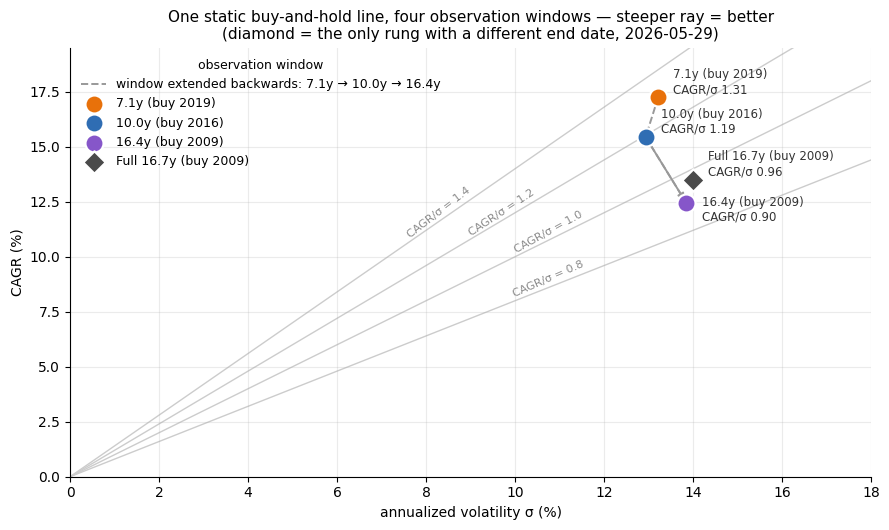

In [3]:
plt.rcParams.update({"font.size": 10, "axes.spines.top": False, "axes.spines.right": False})
INK, MUTED = "#333333", "#8a8a8a"

# ray_panel is nb18's, unchanged — the whole point of this notebook is that the
# grammar is identical and only the meaning of a point differs.
def ray_panel(ax, slopes, slope_fmt, xmax, ymax, frac):
    ax.set_xlim(0, xmax); ax.set_ylim(0, ymax)
    ax.grid(alpha=0.25, zorder=0)
    for s in slopes:
        ax.plot([0, xmax], [0, s * xmax], color="#cccccc", lw=1, zorder=1)
        xe = min(xmax, ymax / s)
        p0 = ax.transData.transform((0.0, 0.0))
        p1 = ax.transData.transform((xe, s * xe))
        ang = np.degrees(np.arctan2(p1[1] - p0[1], p1[0] - p0[0]))
        ax.annotate(slope_fmt.format(s), (frac * xe, frac * s * xe), color=MUTED,
                    fontsize=8, ha="center", va="bottom", rotation=ang,
                    rotation_mode="anchor", xytext=(0, 2), textcoords="offset points")

fig, ax = plt.subplots(figsize=(9.0, 5.4))
ray_panel(ax, (0.8, 1.0, 1.2, 1.4), "CAGR/σ = {:.1f}", 18.0, 19.5, frac=0.60)

# the drift path: the three common-end rungs, shortest window first. Named in the
# legend rather than annotated in place — the points sit ~1.5 units apart, so any
# in-axes caption lands on top of either the path or a point label.
WALK = ["7.1y (buy 2019)", "10.0y (buy 2016)", "16.4y (buy 2009)"]
ax.plot([M[l]["ann_vol"] * 100 for l in WALK], [M[l]["cagr"] * 100 for l in WALK],
        ls="--", lw=1.4, color="#999999", zorder=2,
        label="window extended backwards: 7.1y → 10.0y → 16.4y")
ax.annotate("", xy=(M[WALK[-1]]["ann_vol"] * 100, M[WALK[-1]]["cagr"] * 100),
            xytext=(M[WALK[-2]]["ann_vol"] * 100, M[WALK[-2]]["cagr"] * 100),
            arrowprops=dict(arrowstyle="-|>", color="#999999", lw=1.4), zorder=2)

OFF = {"7.1y (buy 2019)": (11, 3), "10.0y (buy 2016)": (11, 3),
       "16.4y (buy 2009)": (11, -13), "Full 16.7y (buy 2009)": (11, 3)}
for _, lbl, _, _, marker in LADDER:
    d = M[lbl]
    x, y = d["ann_vol"] * 100, d["cagr"] * 100
    ax.scatter(x, y, s=170 if marker == "o" else 130, marker=marker, color=d["color"],
               edgecolor="white", linewidth=1.6, zorder=4, label=lbl)
    ax.annotate(f"{lbl}\nCAGR/σ {d['cagr_over_vol']:.2f}", (x, y), xytext=OFF[lbl],
                textcoords="offset points", fontsize=8.5, color=INK, ha="left")

ax.set_xlabel("annualized volatility σ (%)")
ax.set_ylabel("CAGR (%)")
ax.set_title("One static buy-and-hold line, four observation windows — steeper ray = better\n"
             "(diamond = the only rung with a different end date, 2026-05-29)", fontsize=11)
ax.legend(loc="upper left", frameon=False, fontsize=9, title="observation window",
          title_fontsize=9)
fig.tight_layout()
fig.savefig(DATA / "nb18_2_risk_return_map.png", dpi=300, bbox_inches="tight")
plt.show()

## 2. The ratio ladder — three risk denominators, four windows, one axis

nb18 §2's ladder, re-cut across windows. Each row divides return by a different
risk: total volatility (**Sharpe**, rf=0), worst peak-to-trough loss (**Calmar** =
CAGR/|max DD|), and SPY-regression residual volatility (**Appraisal** =
intercept/σε). All three are unitless, so they share one axis.

**All three denominators tell the same story, and it is a decay.** Every ladder
row is ordered identically — 7.1y, then 10.0y, then the two 2009 rungs — with no
crossings anywhere. That is what makes the finding hard to argue with: it is not
one ratio being sensitive to one window, it is the whole risk-adjusted case
moving together with the start date.

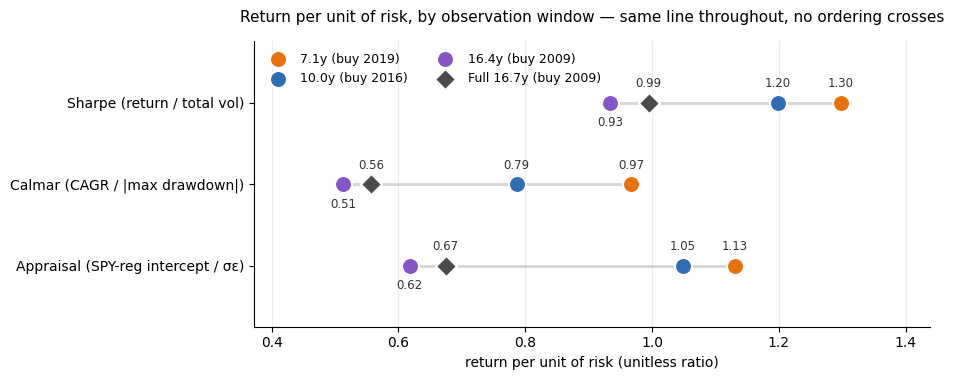

In [4]:
RATIOS = [("Sharpe (return / total vol)", "sharpe"),
          ("Calmar (CAGR / |max drawdown|)", "calmar"),
          ("Appraisal (SPY-reg intercept / σε)", "appraisal")]

# fixed per-window label slot: the two 2009 rungs sit within ~0.06 of each other on
# every row, so a shared "above, centered" slot collides on all three.
SLOT = {"7.1y (buy 2019)": 11, "10.0y (buy 2016)": 11,
        "16.4y (buy 2009)": -17, "Full 16.7y (buy 2009)": 11}

fig, ax = plt.subplots(figsize=(9.5, 3.9))
for i, (row_lbl, key) in enumerate(RATIOS):
    y = len(RATIOS) - 1 - i
    xs = [M[lbl][key] for _, lbl, _, _, _ in LADDER]
    ax.plot([min(xs), max(xs)], [y, y], color="#d5d5d5", lw=2, zorder=1)
    for _, lbl, _, _, marker in LADDER:
        d = M[lbl]
        ax.scatter(d[key], y, s=150 if marker == "o" else 115, marker=marker,
                   color=d["color"], edgecolor="white", linewidth=1.5, zorder=3,
                   label=lbl if i == 0 else None)
        ax.annotate(f"{d[key]:.2f}", (d[key], y), xytext=(0, SLOT[lbl]),
                    textcoords="offset points", ha="center", fontsize=8.5, color=INK)

ax.set_yticks(range(len(RATIOS)), [r for r, _ in reversed(RATIOS)])
ax.set_xlabel("return per unit of risk (unitless ratio)")
# limits from the DATA, not hardcoded — nb18's lesson: a hardcoded window silently
# clips points the moment the metric basis or the window set changes.
_all = [M[lbl][k] for _, lbl, _, _, _ in LADDER for _, k in RATIOS]
_pad = 0.18 * (max(_all) - min(_all))
ax.set_xlim(min(_all) - _pad, max(_all) + _pad)
ax.grid(axis="x", alpha=0.25, zorder=0)
ax.set_ylim(-0.75, 2.75)
ax.legend(loc="upper left", frameon=False, fontsize=9, ncol=2)
ax.set_title("Return per unit of risk, by observation window — same line throughout, "
             "no ordering crosses", fontsize=11, pad=14)
fig.tight_layout()
fig.savefig(DATA / "nb18_2_ratio_ladder.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. The tear sheet — and why SSR is not on either chart

`SSR` is deliberately absent from the risk–return map and the ratio ladder.
Both are "up/steeper = preferable" displays, which presume a rankable quantity,
and SSR is not one: it is a descriptive stability *effect size* whose denominator
carries no √n, so the point estimate has no sampling interpretation. The
inferential claim is the one-sided moving-block-bootstrap p-value and verdict
from `ssr_inference`, printed per window below. nb18 removed SSR from its metric
profile for exactly this reason, and the same reason applies across windows —
arguably more so, since the SSR estimates here are computed on samples of very
different length.

In [5]:
COLS = [("Buy", "start"), ("Hold to", "end"), ("Years (elapsed)", "years"),
        ("Number of days", "n_days"), ("Total Return", "total_return"),
        ("CAGR", "cagr"), ("Ann. Volatility", "ann_vol"), ("CAGR / σ", "cagr_over_vol"),
        ("Sharpe", "sharpe"), ("Max Drawdown", "maxdd"), ("Calmar", "calmar"),
        ("Regression intercept (ann., SPY)", "alpha"),
        ("Residual vol (ann., SPY reg)", "idio"),
        ("Appraisal Ratio (intercept / residual vol)", "appraisal"),
        ("HAC t (intercept)", "t_alpha"), ("R² (SPY regression, rf=0)", "r2"),
        ("Regression days aligned", "n_reg"),
        ("SSR (Sharpe Stability Ratio)", "ssr"), ("SSR MBB p (one-sided)", "ssr_p"),
        ("SSR verdict", "ssr_verdict")]

# built row-wise so each column keeps its own dtype: `to_csv` applies float_format
# and `decimal` per float block, so an all-object frame (e.g. pd.DataFrame(dict).T)
# would ship dot-decimal full-repr floats into the _de mirror.
sheet = pd.DataFrame([
    {"Label": lbl, **{name: (M[lbl][k].date() if k in ("start", "end") else M[lbl][k])
                      for name, k in COLS}}
    for _, lbl, _, _, _ in LADDER
]).set_index("Label")

TEAR = DATA / "tear_sheet"
TEAR.mkdir(exist_ok=True)
sheet.to_csv(TEAR / "tear_sheet_static_bh_window_dashboard.csv", float_format="%.8f")
sheet.to_csv(TEAR / "tear_sheet_static_bh_window_dashboard_de.csv", sep=";", decimal=",",
             float_format="%.8f")

for lbl in sheet.index:
    print(f"{lbl}: {sheet.loc[lbl, 'SSR verdict']}")

sheet.drop(columns=["SSR verdict"]).style.format({
    "Years (elapsed)": "{:.2f}", "Total Return": "{:.1%}", "CAGR": "{:.1%}",
    "Ann. Volatility": "{:.1%}", "CAGR / σ": "{:.2f}", "Sharpe": "{:.2f}",
    "Max Drawdown": "{:.1%}", "Calmar": "{:.2f}",
    "Regression intercept (ann., SPY)": "{:.1%}",
    "Residual vol (ann., SPY reg)": "{:.1%}",
    "Appraisal Ratio (intercept / residual vol)": "{:.2f}",
    "HAC t (intercept)": "{:.2f}", "R² (SPY regression, rf=0)": "{:.3f}",
    "SSR (Sharpe Stability Ratio)": "{:.2f}", "SSR MBB p (one-sided)": "{:.3f}"})

7.1y (buy 2019): SSR=0.14: rolling Sharpe stably > 0 in this sample (one-sided MBB p=0.000 < 0.05) — temporal consistency, not a skill claim
10.0y (buy 2016): SSR=0.15: rolling Sharpe stably > 0 in this sample (one-sided MBB p=0.000 < 0.05) — temporal consistency, not a skill claim
16.4y (buy 2009): SSR=0.12: rolling Sharpe stably > 0 in this sample (one-sided MBB p=0.000 < 0.05) — temporal consistency, not a skill claim
Full 16.7y (buy 2009): SSR=0.12: rolling Sharpe stably > 0 in this sample (one-sided MBB p=0.000 < 0.05) — temporal consistency, not a skill claim


,Buy,Hold to,Years (elapsed),Number of days,Total Return,CAGR,Ann. Volatility,CAGR / σ,Sharpe,Max Drawdown,Calmar,"Regression intercept (ann., SPY)","Residual vol (ann., SPY reg)",Appraisal Ratio (intercept / residual vol),HAC t (intercept),"R² (SPY regression, rf=0)",Regression days aligned,SSR (Sharpe Stability Ratio),SSR MBB p (one-sided)
Label,,,,,,,,,,,,,,,,,,,
7.1y (buy 2019),2019-01-02,2026-01-30,7.08,1745,208.4%,17.3%,13.2%,1.31,1.30,-17.8%,0.97,8.4%,7.4%,1.13,3.58,0.685,1745,0.14,0.000
10.0y (buy 2016),2016-02-01,2026-01-30,10.00,2468,320.1%,15.4%,12.9%,1.19,1.20,-19.6%,0.79,7.4%,7.1%,1.05,3.78,0.701,2468,0.15,0.000
16.4y (buy 2009),2009-09-25,2026-01-30,16.35,4036,580.4%,12.4%,13.8%,0.90,0.93,-24.2%,0.51,4.8%,7.8%,0.62,2.65,0.681,4036,0.12,0.000
Full 16.7y (buy 2009),2009-09-25,2026-05-29,16.67,4115,726.4%,13.5%,14.0%,0.96,0.99,-24.2%,0.56,5.4%,7.9%,0.67,2.90,0.678,4114,0.12,0.000


In [6]:
# The headline, stated as arithmetic rather than as a claim: how much of each
# ratio survives the walk from the 7.1-year window to the 16.4-year one.
short, long_ = M["7.1y (buy 2019)"], M["16.4y (buy 2009)"]
print("Same basket, same construction, same 2026-01-30 end — only the buy date moves.")
# the last column is long/short as a RATIO, not "retained": on the two risk rows a
# value above 100% means the long window is worse, not that more of it survived.
print(f"{'':<34s}{'7.1y (2019)':>12s}{'16.4y (2009)':>14s}{'16.4y / 7.1y':>14s}")
for name, key, good in [("CAGR", "cagr", True), ("Annualized volatility σ", "ann_vol", False),
                        ("Max drawdown", "maxdd", False), ("Sharpe", "sharpe", True),
                        ("Calmar", "calmar", True), ("Appraisal (SPY reg)", "appraisal", True),
                        ("SPY-reg intercept (ann.)", "alpha", True)]:
    ratio = long_[key] / short[key]
    tag = "" if good else "  (risk: >100% = worse)"
    print(f"  {name:<32s}{short[key]:>12.4f}{long_[key]:>14.4f}{ratio:>13.0%}{tag}")
print(f"\n  Sharpe ladder: {short['sharpe']:.2f} (7.1y) → "
      f"{M['10.0y (buy 2016)']['sharpe']:.2f} (10.0y) → {long_['sharpe']:.2f} (16.4y)")

Same basket, same construction, same 2026-01-30 end — only the buy date moves.
                                   7.1y (2019)  16.4y (2009)  16.4y / 7.1y
  CAGR                                  0.1725        0.1245          72%
  Annualized volatility σ               0.1322        0.1385         105%  (risk: >100% = worse)
  Max drawdown                         -0.1785       -0.2424         136%  (risk: >100% = worse)
  Sharpe                                1.2972        0.9343          72%
  Calmar                                0.9666        0.5133          53%
  Appraisal (SPY reg)                   1.1302        0.6176          55%
  SPY-reg intercept (ann.)              0.0839        0.0483          58%

  Sharpe ladder: 1.30 (7.1y) → 1.20 (10.0y) → 0.93 (16.4y)


## Reading guide

- **The points are windows, not strategies.** Nothing on either chart is being
  ranked against anything else. There is one line here; the AI macro-factor and
  SJM×crowding seats of `15_2` / `18` are absent by necessity, since their inputs
  are LLM outputs that do not exist before 2019-01-03. Any comparison against
  those lines must be made on the trio's own window, in `15_2` / `18`, never
  against these charts.
- **The decay is the finding, and it is not small.** Extending the window
  backwards from 2019 to 2009 — same basket, same construction, same end date —
  costs roughly **28% of the Sharpe** (1.30 → 0.93), **47% of the Calmar**
  (0.97 → 0.51) and **45% of the appraisal ratio** (1.13 → 0.62). The ordering is
  identical on all three denominators with no crossings, so this is not one
  fragile ratio; the whole risk-adjusted case moves with the start date.
- **Volatility barely moves; return and drawdown do.** σ sits in a 12.9–14.0%
  band across every window, so the decay is not the long window being *riskier*
  in the vol sense. It is the long window earning less per year (CAGR 17.25% →
  12.45%) and containing a worse worst case (max drawdown -17.85% → -24.24%,
  the 2022 episode). More history adds a long, shallow decade the short window
  never had to survive.
- **Quote the 7.1-year figure and you are quoting a start-date choice as a
  portfolio property.** That is the honest one-line summary of this notebook.
  The trio's window is the trio's window for a defensible reason — it is where
  the LLM scores begin — but the static benchmark's risk-adjusted strength on it
  is substantially an artifact of 2019.
- **Still in-sample at every length.** The basket was SSR-selected over an
  overlapping window, so no rung here is an out-of-sample result. More history
  does not launder a hindsight selection.
- **SSR stays descriptive.** The SSR column is a stability effect size; the claim
  is carried by the one-sided MBB verdict from `ssr_inference` printed in §3.
  "Stably above zero in this realized sample" is temporal consistency, never a
  skill claim, and it is a per-window verdict, not a ranking — the gaps between
  the SSR point estimates carry no inferential meaning, least of all across
  samples of 1745 vs 4115 days.

Artifacts written by this notebook: `data/nb18_2_risk_return_map.png` and
`data/nb18_2_ratio_ladder.png` at 300 dpi, plus
`data/tear_sheet/tear_sheet_static_bh_window_dashboard.csv` (+ `_de` German-locale
mirror). Equity artifacts come from `scripts/build_static_bh_long.py`; the
price-only SPY benchmark from `scripts/build_spy_long.py`, which keeps the
published `etf_prices_wide_2013_2026.parquet` column verbatim from 2013 on and
only prepends 2009–2012 (verified in the self-check cell).